# Exploring BDEW Standard Load Profiles with demandlib

This notebook explores the [BDEW Standardlastprofile](https://www.bdew.de/energie/standardlastprofile-strom/) (Standard Load Profiles) using the [demandlib](https://github.com/oemof/demandlib) Python library.

## What is BDEW H0?
The BDEW (German Association of Energy and Water Industries) defines standard load profiles for different consumer types. **H0** is the profile for residential households.

## Why demandlib?
- Generates realistic household consumption patterns
- Based on official German utility standards
- Accounts for seasonal variation, weekday/weekend differences, and time-of-day patterns

## Key Insight
A typical German household consumes ~3,500 kWh/year, with hourly values ranging from 0.13 to 0.73 kWh. Our synthetic data uses higher values (0.2-2.2 kWh) to create more dramatic optimization opportunities in the workshop.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from demandlib import bdew

## Generate Load Profile

The `get_scaled_power_profiles()` method returns power values (kW) at 15-minute intervals, scaled to match the specified annual consumption.

In [2]:
slp = bdew.ElecSlp(year=2024)

annual_demand_kwh = 3500
profile = slp.get_scaled_power_profiles({'h0': annual_demand_kwh})

print(f"Profile shape: {profile.shape}")
print(f"Resolution: 15-minute intervals (values are power in kW)")
profile.head()

Profile shape: (35136, 1)
Resolution: 15-minute intervals (values are power in kW)


,h0
2024-01-01 00:00:00,0.236388
2024-01-01 00:15:00,0.212749
2024-01-01 00:30:00,0.191908
2024-01-01 00:45:00,0.174563
2024-01-01 01:00:00,0.161695


## Convert to Hourly Resolution

In [3]:
# Use mean() because profile contains power (kW), not energy
# Average kW over 1 hour = kWh consumed in that hour
hourly = profile.resample('h').mean()
print(f"Annual consumption: {hourly['h0'].sum():.0f} kWh")
print(f"Daily average: {hourly['h0'].sum() / 366:.1f} kWh")
print(f"Hourly average: {hourly['h0'].mean():.3f} kWh")
hourly.describe()

Annual consumption: 3500 kWh
Daily average: 9.6 kWh
Hourly average: 0.398 kWh


,h0
count,8784.000000
mean,0.398452
std,0.155821
min,0.134489
25%,0.257544
50%,0.430883
75%,0.505515
max,0.734760


## Full Year Visualization

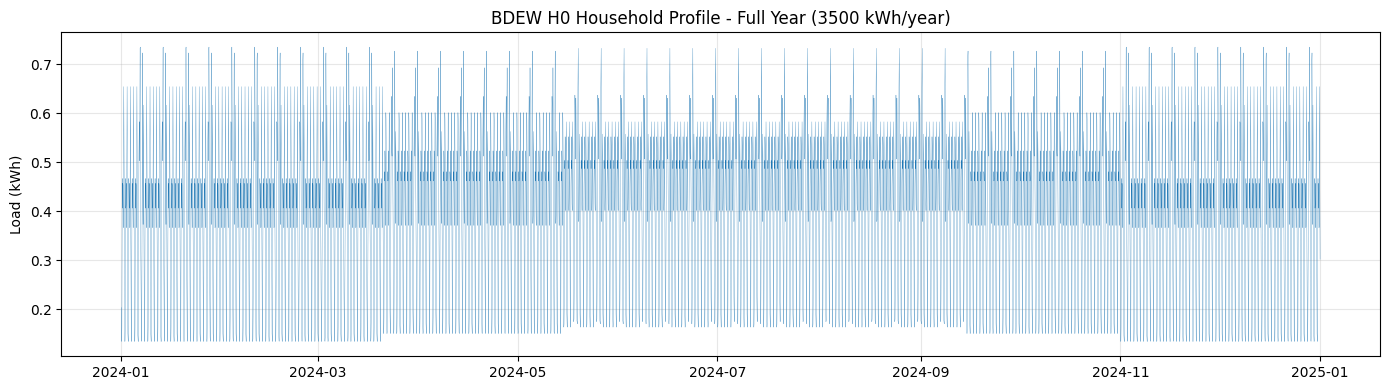

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly.index, hourly['h0'], linewidth=0.2)
ax.set_ylabel('Load (kWh)')
ax.set_title('BDEW H0 Household Profile - Full Year (3500 kWh/year)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Seasonal Comparison: Winter vs Summer Week

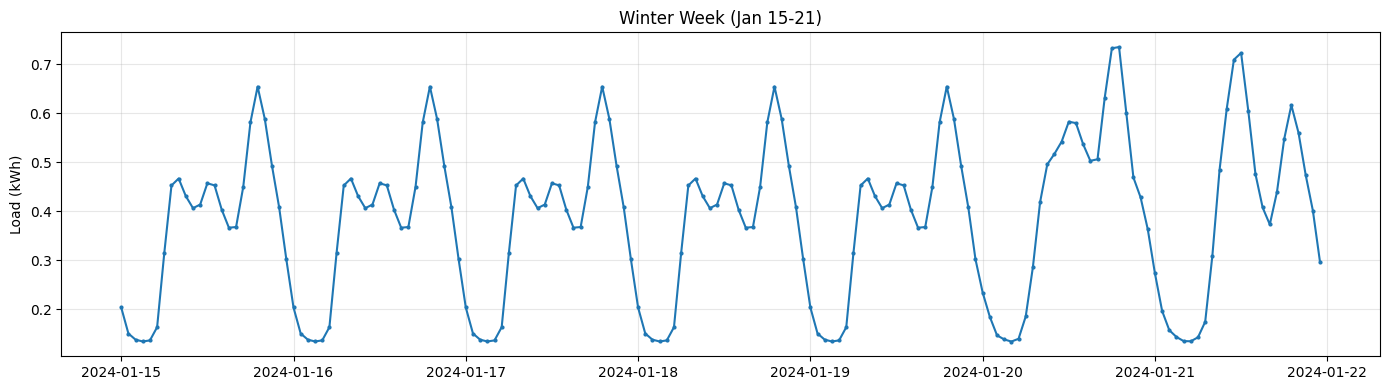

In [5]:
week_winter = hourly['2024-01-15':'2024-01-21']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(week_winter.index, week_winter['h0'], marker='o', markersize=2)
ax.set_ylabel('Load (kWh)')
ax.set_title('Winter Week (Jan 15-21)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

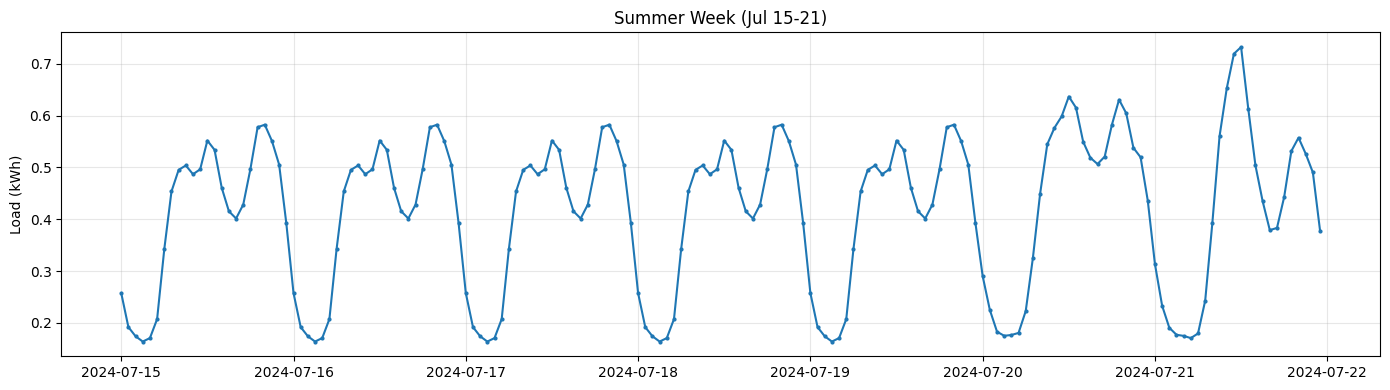

In [6]:
week_summer = hourly['2024-07-15':'2024-07-21']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(week_summer.index, week_summer['h0'], marker='o', markersize=2)
ax.set_ylabel('Load (kWh)')
ax.set_title('Summer Week (Jul 15-21)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Weekday vs Weekend Patterns

Analyze the average hourly load by time of day, separated by weekday and weekend.

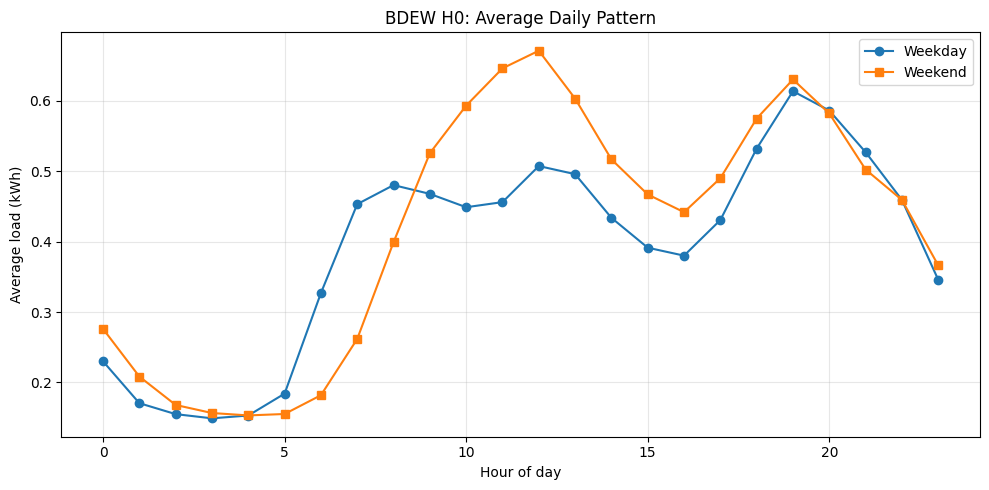

In [7]:
hourly['hour'] = hourly.index.hour
hourly['dayofweek'] = hourly.index.dayofweek
hourly['is_weekend'] = hourly['dayofweek'] >= 5

weekday_pattern = hourly[~hourly['is_weekend']].groupby('hour')['h0'].mean()
weekend_pattern = hourly[hourly['is_weekend']].groupby('hour')['h0'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weekday_pattern.index, weekday_pattern.values, label='Weekday', marker='o')
ax.plot(weekend_pattern.index, weekend_pattern.values, label='Weekend', marker='s')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average load (kWh)')
ax.set_title('BDEW H0: Average Daily Pattern')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary by Time Period

Compare average hourly consumption across different times of day.

In [8]:
print("Average hourly load (kWh) by time period:")
print("\nWeekday:")
print(f"  Night (00-06):   {weekday_pattern[0:7].mean():.3f}")
print(f"  Morning (07-09): {weekday_pattern[7:10].mean():.3f}")
print(f"  Midday (10-16):  {weekday_pattern[10:17].mean():.3f}")
print(f"  Evening (17-21): {weekday_pattern[17:22].mean():.3f}")
print(f"  Night (22-23):   {weekday_pattern[22:24].mean():.3f}")

print("\nWeekend:")
print(f"  Night (00-06):   {weekend_pattern[0:7].mean():.3f}")
print(f"  Morning (07-09): {weekend_pattern[7:10].mean():.3f}")
print(f"  Midday (10-16):  {weekend_pattern[10:17].mean():.3f}")
print(f"  Evening (17-21): {weekend_pattern[17:22].mean():.3f}")
print(f"  Night (22-23):   {weekend_pattern[22:24].mean():.3f}")

Average hourly load (kWh) by time period:

Weekday:
  Night (00-06):   0.195
  Morning (07-09): 0.467
  Midday (10-16):  0.445
  Evening (17-21): 0.538
  Night (22-23):   0.402

Weekend:
  Night (00-06):   0.186
  Morning (07-09): 0.395
  Midday (10-16):  0.563
  Evening (17-21): 0.556
  Night (22-23):   0.413
